In [7]:
!pip install pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [8]:
import pandas as pd
#load the dataset
df=pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
#see first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
#check data size
print("shape:", df.shape)
print("\nColumn names:", df.columns.tolist())

shape: (9994, 21)

Column names: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [10]:
#check data types
print(df.dtypes)

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [11]:
#check missing value
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [12]:
#basic statistics
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [13]:
#Fix data columns --convert text to proper date format
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])

#Extract year and month for later analysis
df['Order Year']=df['Order Date'].dt.year
df['Order Month']=df['Order Date'].dt.month

#Confirm the fix
print(df[['Order Date','Ship Date','Order Month','Order Year']].head())
print("\nNew dtypes:")
print(df[['Order Date','Ship Date']].dtypes)
    

  Order Date  Ship Date  Order Month  Order Year
0 2016-11-08 2016-11-11           11        2016
1 2016-11-08 2016-11-11           11        2016
2 2016-06-12 2016-06-16            6        2016
3 2015-10-11 2015-10-18           10        2015
4 2015-10-11 2015-10-18           10        2015

New dtypes:
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [14]:
#total sales by category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


In [17]:
#total profit by region
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print(region_profit)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


In [18]:
#top 10 states
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False)
print(top_states)

State
California              457687.6315
New York                310876.2710
Texas                   170188.0458
Washington              138641.2700
Pennsylvania            116511.9140
Florida                  89473.7080
Illinois                 80166.1010
Ohio                     78258.1360
Michigan                 76269.6140
Virginia                 70636.7200
North Carolina           55603.1640
Indiana                  53555.3600
Georgia                  49095.8400
Kentucky                 36591.7500
New Jersey               35764.3120
Arizona                  35282.0010
Wisconsin                32114.6100
Colorado                 32108.1180
Tennessee                30661.8730
Minnesota                29863.1500
Massachusetts            28634.4340
Delaware                 27451.0690
Maryland                 23705.5230
Rhode Island             22627.9560
Missouri                 22205.1500
Oklahoma                 19683.3900
Alabama                  19510.6400
Oregon                

In [20]:
#Sales by month
monthly_sales = df.groupby('Order Month')['Sales'].sum()
print(monthly_sales)

Order Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64


In [21]:
#Sales by customer segment
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
print(segment_sales)

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

#Make chart look beautiful
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']=(10,5)

print("Chart setup done!")

Chart setup done!


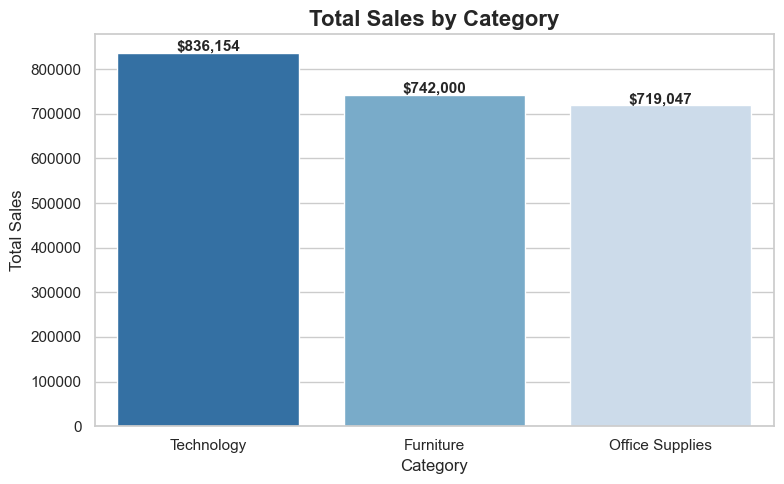

In [30]:
#CHART 1 - Sales by Category (Bar Chart)
plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.index, y=category_sales.values, hue=category_sales.index, palette='Blues_r', legend=False)

plt.title('Total Sales by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)

#add value labels on top of each bar
for i, v in enumerate(category_sales.values):
    plt.text(i, v + 5000, f'${v:,.0f}', ha='center',fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('chart1_category_sales.png') #save chart as image
plt.show()

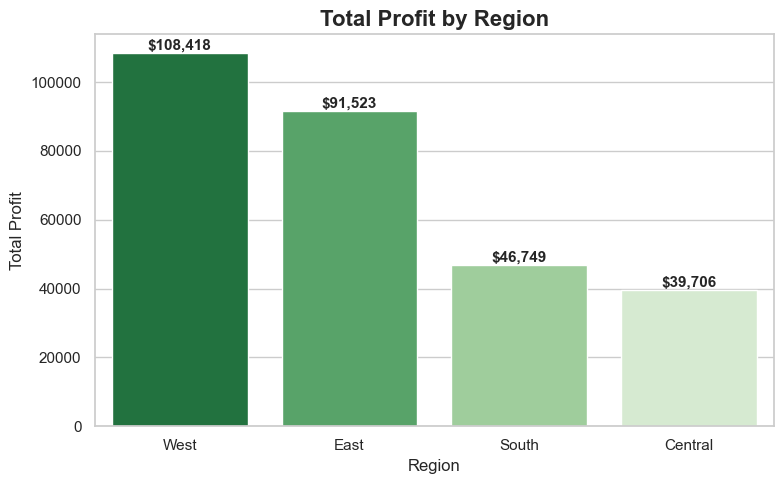

In [33]:
#CHART 2 -- Profit by region (Bar Chart)
plt.figure(figsize=(8, 5))
sns.barplot(x=region_profit.index, y=region_profit.values, hue=region_profit.index, palette='Greens_r', legend=False)

plt.title('Total Profit by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Profit', fontsize=12)

#Add value labels on top of each bar
for i , v in enumerate(region_profit.values):
    plt.text(i, v + 1000, f'${v:,.0f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('Chart2_region_profit.png')
plt.show()



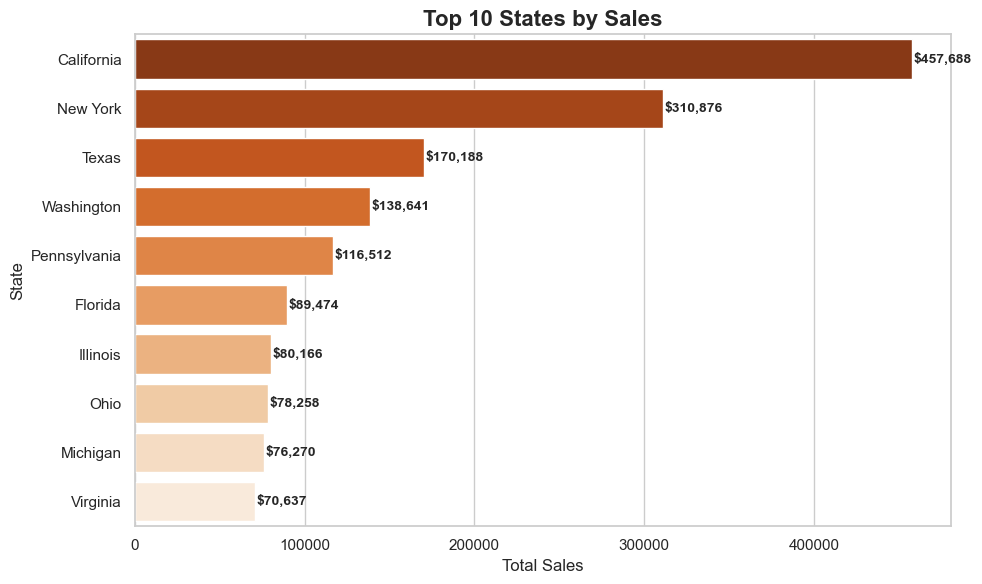

In [36]:
#CHART 3 -- Top 10 States by sales(Horizontal Bar Chart)
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_states.values, y=top_states.index, hue=top_states.index, palette='Oranges_r', legend=False)

plt.title('Top 10 States by Sales', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales', fontsize=12)
plt.ylabel('State', fontsize=12)

for i, v in enumerate(top_states.values):
    plt.text(v + 1000, i, f'${v:,.0f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('chart3_top_states.png')
plt.show()


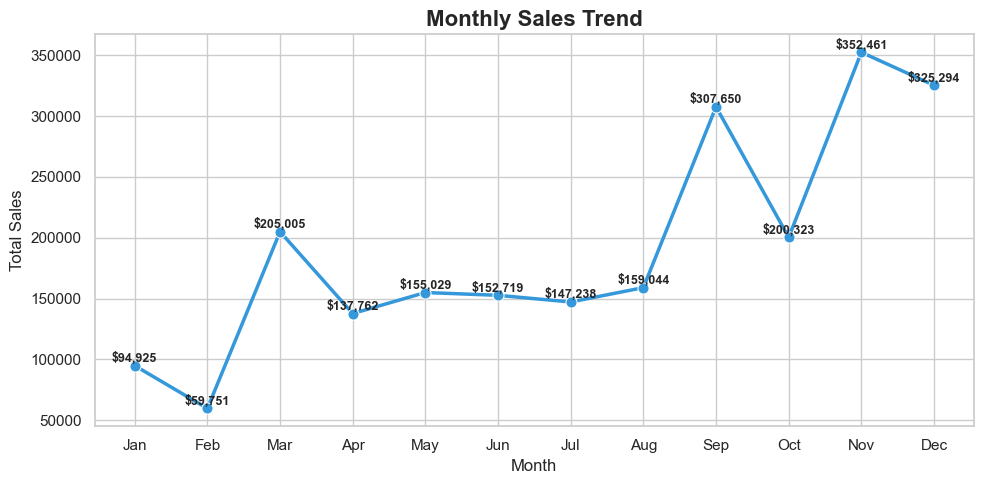

In [38]:
#CHART 4 -- Monthly Sales trend (line chart)
plt.figure(figsize=(10, 5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, color='#3498db', linewidth=2.5, marker='o', markersize=8)

#add value labels on each point
for i, v in enumerate(monthly_sales.values):
    plt.text(i+1, v + 3000, f'${v:,.0f}', ha='center', fontsize=9, fontweight='bold')

plt.title('Monthly Sales Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month',fontsize=12)
plt.ylabel('Total Sales', fontsize=12)

#replace numbers with month names
plt.xticks(ticks=range(1, 13), labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

plt.tight_layout()
plt.savefig('chart4_monthly_trend.png')
plt.show()

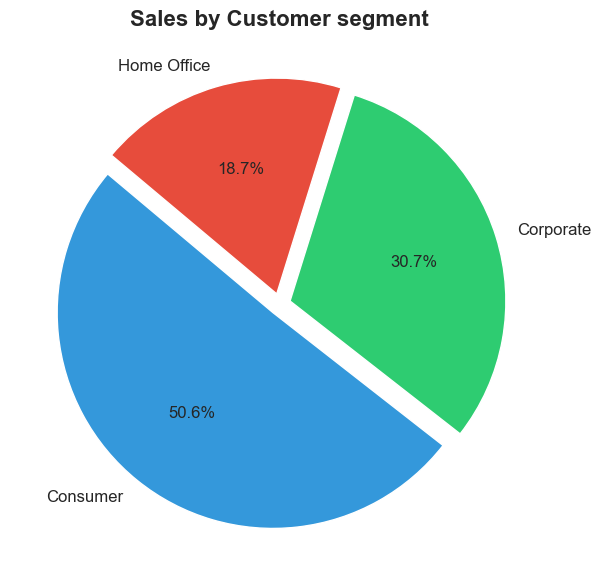

In [39]:
#CHART 5 -- Sales by customer segment(pie Chart)
plt.figure(figsize=(8, 6))

colors = ['#3498db', '#2ecc71', '#e74c3c']
explode = (0.05, 0.05, 0.05) #slightly separate each slice

plt.pie(segment_sales.values, labels=segment_sales.index, autopct='%1.1f%%', colors=colors, explode=explode, startangle=140, textprops={'fontsize':12})

plt.title('Sales by Customer segment', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_segment_pie.png')
plt.show()

In [41]:
# PROJECT INSIGHTS & BUSINESS RECOMMENDATIONS
print("""
===============================================
     SUPERSTORE SALES ANALYSIS --INSIGHTS
===============================================

1.CATEGORY PERFORMANCE:
   - Technology is the top selling category ($836,154)
   - All 3 categories are close in sales
   - Recommendation: Focus promotions on Technology

2.REGIONAL PROFIT:
   - West region is most profitable ($108,418)
   - Central region needs improvement ($39,706)
   - Recommendation: Investigate why Central lags behind

3. TOP STATES:
   - California dominates with $457,688 in sales
   - Top 3 states (CA, NY, TX) = 41% of total sales
   - Recommendation: Expand marketing in other states

4. MONTHLY TREND:
   - November is peak sales month ($352,461)
   - February is lowest ($59,751)
   - Recommendation: Run promotions in Feb to boost sales
   - Sales spike every quarter end (Mar, Jun, Sep, Dec)

5. CUSTOMER SEGMENT:
   - Consumer segment = 50.6% of all sales
   - Corporate = 30.7%, Home Office = 18.7%
   - Recommendation: Target Consumer segment for max growth

==============================================
     CONCLUSION: Focus on West region,
     Technology category, and Consumer
     segment for maximum business growth!
==============================================
""")


     SUPERSTORE SALES ANALYSIS --INSIGHTS

1.CATEGORY PERFORMANCE:
   - Technology is the top selling category ($836,154)
   - All 3 categories are close in sales
   - Recommendation: Focus promotions on Technology

2.REGIONAL PROFIT:
   - West region is most profitable ($108,418)
   - Central region needs improvement ($39,706)
   - Recommendation: Investigate why Central lags behind

3. TOP STATES:
   - California dominates with $457,688 in sales
   - Top 3 states (CA, NY, TX) = 41% of total sales
   - Recommendation: Expand marketing in other states

4. MONTHLY TREND:
   - November is peak sales month ($352,461)
   - February is lowest ($59,751)
   - Recommendation: Run promotions in Feb to boost sales
   - Sales spike every quarter end (Mar, Jun, Sep, Dec)

5. CUSTOMER SEGMENT:
   - Consumer segment = 50.6% of all sales
   - Corporate = 30.7%, Home Office = 18.7%
   - Recommendation: Target Consumer segment for max growth

     CONCLUSION: Focus on West region,
     Technology cate